# Soal 1 - Transformasi Citra
Transformasi negatif dan logaritmik pada citra grayscale.

/tmp/ipykernel_2826/3738293977.py:39: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(images[i].ravel(), 256, [0,256])


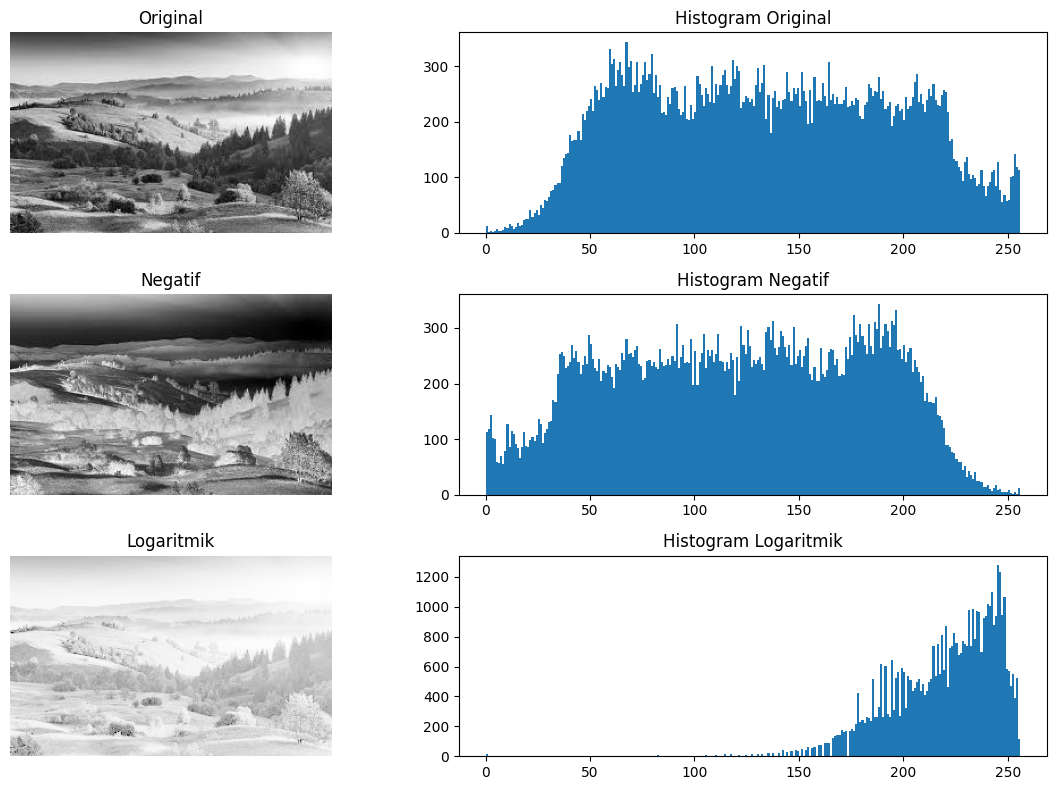

True

In [4]:
# IMPORT LIBRARY
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# BUAT FOLDER OUTPUT JIKA BELUM ADA
os.makedirs('output', exist_ok=True)

# LOAD GAMBAR
# Perbaikan: Mengubah path gambar dari 'input/gambar1.jpg' menjadi '/content/gambar1.jpg'
img = cv2.imread('/content/gambar1.jpg', 0)
if img is None:
    raise ValueError("Gambar1.jpg")

# TRANSFORMASI NEGATIF
negatif = 255 - img

# TRANSFORMASI LOGARITMIK
# Konversi gambar ke float64 untuk menghindari overflow dan masalah presisi dengan logaritma
img_float = img.astype(np.float64)
c = 255 / np.log(1 + np.max(img_float))
log_img_float = c * np.log(1 + img_float)
# Normalisasi dan konversi kembali ke uint8
log_img = np.array(log_img_float, dtype=np.uint8)

# VISUALISASI + HISTOGRAM
titles = ['Original', 'Negatif', 'Logaritmik']
images = [img, negatif, log_img]

plt.figure(figsize=(12,8))
for i in range(3):
    plt.subplot(3,2,2*i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

    plt.subplot(3,2,2*i+2)
    plt.hist(images[i].ravel(), 256, [0,256])
    plt.title('Histogram ' + titles[i])

plt.tight_layout()
plt.show()

# SIMPAN OUTPUT
cv2.imwrite('output/original.png', img)
cv2.imwrite('output/negatif.png', negatif)
cv2.imwrite('output/logaritmik.png', log_img)
